**Empirical Calibration Using NBA Play-by-Play Data**

This notebook makes use play-by-play data taken from the 2022-23 season via NBAStuffer, the purpose of this stage of research is to calibrate the theoretical baseline model and begin to understand what real world basketball data tells us in comparison to the theory work from the original baseline model

**NOTE TO ASSESSORS**

Due to the size of the file, after uploading the 2022-23 play-by-play csv on google colab, please wait for the file to fully load before running the code cells to ensure reproducibility, once the blue circle is full (see screenshot below) this means the csv has fully loaded and the code can be run. **The same must be done for the Game_Clock_Ext, Defensive_Matchup_Ext and Fatigue_Ext notebooks.**

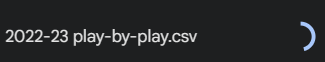

**Import required libraries and read dataset**

In [ ]:
# import required libraries for analysis
!pip install nashpy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import nashpy as nash

# from google.colab import drive
# drive.mount('/content/drive')
# df = pd.read_csv('/content/drive/MyDrive/2022-23 play-by-play.csv')

# read 2022-23 play-by-play dataset
df = pd.read_csv('2022-23 play-by-play.csv')

**Extract all 3 Point attempts from the dataset and clean data**

In [ ]:
# extract all 3 point attempts from season dataset
three_point_shot = df[(df['event_type'] == 'shot')
& (df['shot_distance'] >= 22)].copy()

print(f"\nTotal 3PT atttempts: {len(three_point_shot)}")


Total 3PT atttempts: 91233


In [ ]:
# extract 3PT information
three_pt = three_point_shot.dropna(subset=
['player','result','shot_distance']).copy()
three_pt['made'] = (three_pt['result']
                              == 'made').astype(int)

# create variables for results
total_attempts = len(three_pt)
scored_attempts = three_pt['made'].sum()
missed_attempts = total_attempts - scored_attempts
three_pt_percentage = (scored_attempts / total_attempts) * 100
empirical_model = three_pt_percentage

# print results
print(f"3-Point attempts made: {scored_attempts}")
print(f"3-Point attempts missed: {missed_attempts}")
print(f"3PT%: {three_pt_percentage:.3f}%")

3-Point attempts made: 32865
3-Point attempts missed: 58368
3PT%: 36.023%


**Record Key Variables**

This code aims to extract all the key information and variables needed (shot and drive actions) to be able to conduct empirical calibration

In [ ]:
# function used to classify offensive actions
def find_actions(row):
  # get shot distance
  event_type = str(row['event_type']).lower() if pd.notna(row['event_type']) else ''
  shot_distance = row['shot_distance']

  # if the shot is greater than or equal to 22 this is a 3PT shot
  # a shot less than 10 is considered a drive
  if event_type == 'shot' and pd.notna(shot_distance):
    if shot_distance >= 22:
      return 'Shoot'
    elif shot_distance < 10:
      return 'Drive'
  return 'Other'

# apply function to dataframe
df['action_category'] = df.apply(find_actions, axis=1)
all_actions_df = df.copy()

# get the number of times each action appears in the dataset
num_actions = all_actions_df['action_category'].value_counts()

**Finding contested and uncontested 3PT**

In [ ]:
# create function for defensive pressure/contest level
def find_contest_level(row):
  # get coordinates of shot location
  x, y = row['converted_x'], row['converted_y']

  # define defensive pressure based on shot location
  if abs(y) > 20 and x > 40:
    return 'Sag Off'

  if abs(y) < 15 and x > 30:
    return 'Moderate Contest'

  return 'Hard-Close Out'

# apply to 3PT dataframe
three_pt['contest_estimate'] = (three_pt.apply(find_contest_level, axis=1))

# compute the number of attempts, the number of attmepts scored and the %
contest_analysis = (three_pt.groupby('contest_estimate')['made']
                    .agg(Attempts='count', Scored='sum', Percentage=lambda x:
                         100 * x.mean()))

# print distribution
print("3PT% by Estimated Contest Level:")
print(contest_analysis)

3PT% by Estimated Contest Level:
                  Attempts  Scored  Percentage
contest_estimate                              
Hard-Close Out       66938   23884   35.680779
Moderate Contest      6190    2350   37.964459
Sag Off              18105    6631   36.625242


**Finding action frequencies**

In [ ]:
# total shoot and drive actions
total_actions = num_actions[['Shoot', 'Drive']].sum()

# get % for each action
shoot = (num_actions.get('Shoot', 0) / total_actions) * 100
drive = (num_actions.get('Drive', 0) / total_actions) * 100

# print distribution
print("Empirical Model action frequencies")
print(f"Shoot {shoot:.2f}%")
print(f"Drive {drive:.2f}%")

Empirical Model action frequencies
Shoot 47.11%
Drive 52.89%


**Get Expected Points per action**

In [ ]:
# league averages from baseline model
foul_rate = 0.133
ft_shoot_value = 2.343
ft_drive_value = 1.562
turnover = 0.141

# get fg% per contest type
shoot_contest = (
    three_pt.groupby('contest_estimate')['made']
    .agg(Attempts='count', Makes='sum', FG='mean')
    .reset_index()
)

# expected points calculation for shoot
shoot_contest['EP'] = shoot_contest['FG'] * 3 + (foul_rate * ft_shoot_value)
shoot_contest = shoot_contest.drop(columns='FG')

# compute baseline drive fg%
drive_fg_pct = (
    all_actions_df.loc[(
        all_actions_df['action_category'] == 'Drive'
    ) & (
        all_actions_df['result'].notna()
    ), 'result'].eq('made').mean()
)

# expected points for baseline drive
baseline_drive_ep = drive_fg_pct * 2 * (1 - turnover) + (foul_rate * ft_drive_value)

# apply defensive contest pressure
drive_ep_empirical_values = [
    float(round(baseline_drive_ep + 0.05, 3)),
    float(round(baseline_drive_ep, 3)),
    float(round(baseline_drive_ep - 0.05, 3))
]

# print distribution
print('Empirical Model Shoot EP based on defensive action')
print()
print(shoot_contest)

print()
print('Empirical Model Drive EP based on defensive action')
print(drive_ep_empirical_values)

Empirical Model Shoot EP based on defensive action

   contest_estimate  Attempts  Makes        EP
0    Hard-Close Out     66938  23884  1.382042
1  Moderate Contest      6190   2350  1.450553
2           Sag Off     18105   6631  1.410376

Empirical Model Drive EP based on defensive action
[1.272, 1.222, 1.172]


**Compute Nash Equilibria**

In [ ]:
# define defensive contests
contests = ['Hard-Close Out', 'Moderate Contest', 'Sag Off']

# extract empirical model shoot ep values
shoot_ep_empirical = (
    shoot_contest.set_index('contest_estimate')
    .reindex(contests)['EP']
    .fillna(1.074)
    .round(2)
    .to_list()
)

drive_ep_empirical = drive_ep_empirical_values

# create payoff matrix
payoff_matrix = np.vstack(
    [shoot_ep_empirical, drive_ep_empirical]
)

# print payoff matrix
print('Empirical Payoff Matrix')
print(pd.DataFrame(payoff_matrix,
                   index=['Shoot', 'Drive'],
                   columns=contests).round(3))

# print nash equilibria based on computed matrix
game = nash.Game(payoff_matrix, -payoff_matrix)
emp_offence, emp_defence = next(game.support_enumeration())
print('Nash Equilibrium from Empirical Model Matrix')
print(f'Shoot: {round (emp_offence[0]*100, 2)}%')
print(f'Shoot: {round (emp_offence[1]*100, 2)}%')
print()

Empirical Payoff Matrix
       Hard-Close Out  Moderate Contest  Sag Off
Shoot           1.380             1.450    1.410
Drive           1.272             1.222    1.172
Nash Equilibrium from Empirical Model Matrix
Shoot: 100.0%
Shoot: 0.0%



**Visualisations to compare models and summarise data collection**

Comparison table

In [ ]:
"""
this section of the notebook creates a comparison table between the baseline
and empirical model to be able to visualise the shooting and drive % as well
as the expected points for shoot and drive per each defensive action/contest
"""

# define comparison table and its values
comparison_table = pd.DataFrame({
    'Values': [
        'Shoot frequency (%)',
        'Drive frequency (%)',
        'Shoot EP (H)',
        'Shoot EP (M)',
        'Shoot EP (SO)',
        'Drive EP (H)',
        'Drive EP (M)',
        'Drive EP (SO)'
    ],
    'Baseline Model': [
        74.14,25.86,
        1.397,1.338,1.368,
        1.498,1.412,1.326
    ],
    'Empirical Model': [
        round(shoot, 2), round(drive,2),
        *payoff_matrix[0],
        *payoff_matrix[1]
    ]
})

# get the difference between baseline and empirical
comparison_table['Difference'] = (
    comparison_table['Baseline Model'] -
    comparison_table['Empirical Model']
).round(2)

# print comparison table
print('Baseline vs Empirical Comparison (frequency and expected points)')
print()
print(comparison_table.to_string(index=False))

Baseline vs Empirical Comparison (frequency and expected points)

             Values  Baseline Model  Empirical Model  Difference
Shoot frequency (%)          74.140           47.110       27.03
Drive frequency (%)          25.860           52.890      -27.03
       Shoot EP (H)           1.397            1.380        0.02
       Shoot EP (M)           1.338            1.450       -0.11
      Shoot EP (SO)           1.368            1.410       -0.04
       Drive EP (H)           1.498            1.272        0.23
       Drive EP (M)           1.412            1.222        0.19
      Drive EP (SO)           1.326            1.172        0.15


Baseline vs Empirical Expected Points

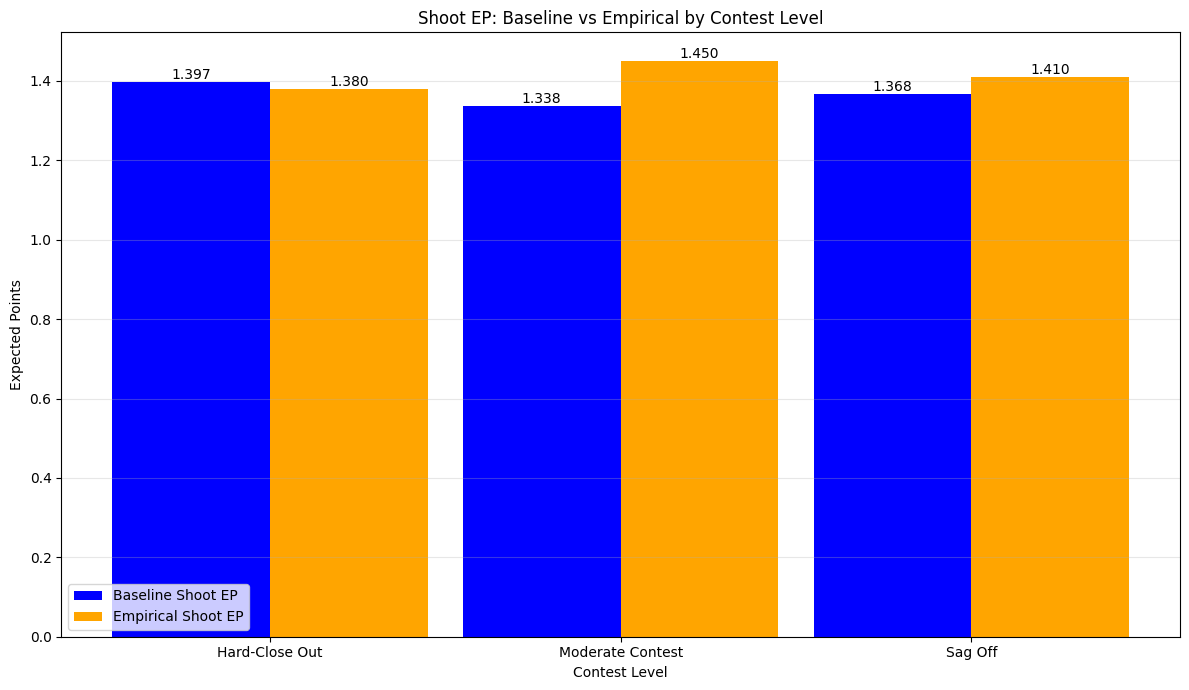

In [ ]:
# create graph
fig, br = plt.subplots(figsize=(12, 7))

# define contest labels and baseline values for plotting
contest_labels = ['Hard-Close Out', 'Moderate Contest', 'Sag Off']
baseline_shoot = [1.397, 1.338, 1.368]
baseline_drive = [1.498, 1.412, 1.326]

#label x axis as contest labels
x = np.arange(len(contest_labels))
width = 0.45

# plot baseline bar
br.bar(x - width/2, baseline_shoot, width, label='Baseline Shoot EP', color='blue')
# plot empirical bar
br.bar(x + width/2, payoff_matrix[0], width, label='Empirical Shoot EP', color='orange')

# plot graph details
br.set_xticks(x)
br.set_xticklabels(contest_labels)
br.set_xlabel('Contest Level')
br.set_ylabel('Expected Points')
br.set_title('Shoot EP: Baseline vs Empirical by Contest Level')
br.legend()
br.grid(axis='y', alpha=0.3)

# add % labels on the bars
for bars in br.containers:
    br.bar_label(bars, fmt='%.3f')

# show graph output
plt.tight_layout()
plt.show()

Baseline vs Empirical action frequencies

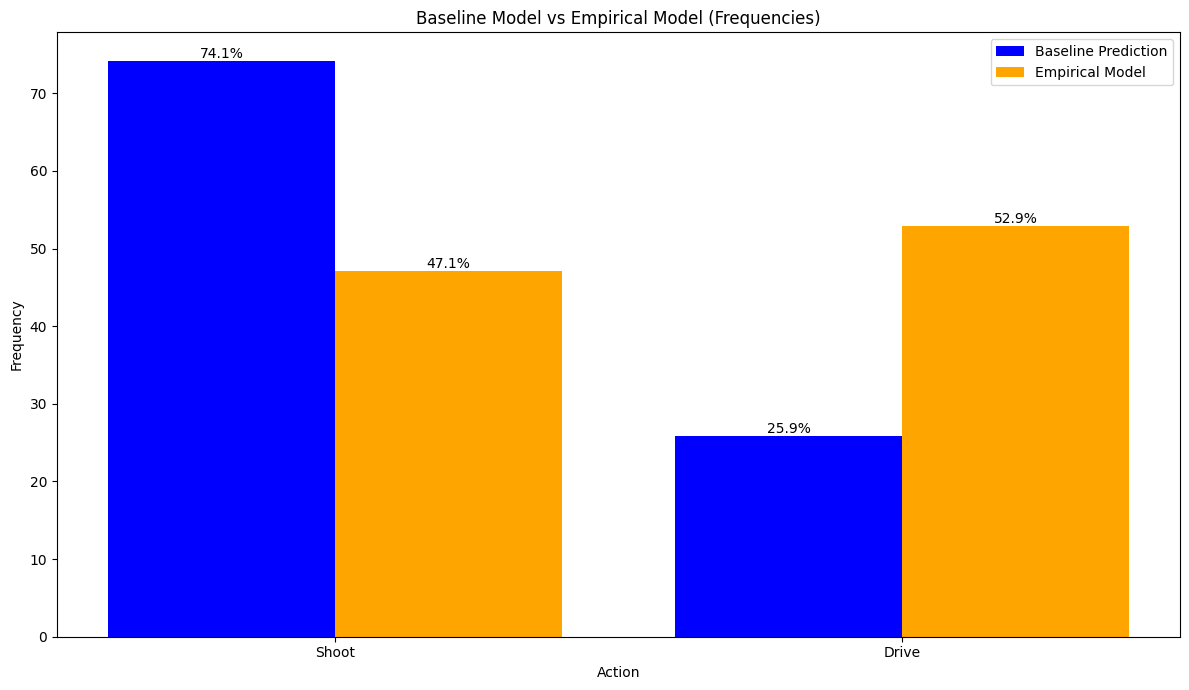

In [ ]:
# create graph
fig, br = plt.subplots(figsize=(12,7))

# define action labels
actions = ['Shoot', 'Drive']

# baseline and empirical values computed earlier
baseline = [74.14, 25.86]
empirical = [shoot, drive]

# label x axis as actions
x = np.arange(len(actions))
width = 0.40

# plot baseline bar
br.bar(x - 0.2, baseline, width, label='Baseline Prediction', color='blue')
# plot empirical bar
br.bar(x + 0.2, empirical, width, label='Empirical Model', color='orange')

# plot graph details
br.set_xticks(x)
br.set_ylabel('Frequency')
br.set_xlabel('Action')
br.set_xticklabels(actions)
br.set_title('Baseline Model vs Empirical Model (Frequencies)')
br.legend()

# add % label
for bars in br.containers:
  br.bar_label(bars, fmt='%.1f%%')

# show graph output
plt.tight_layout()
plt.show()

Baseline vs Empirical action frequencies with Nash computation

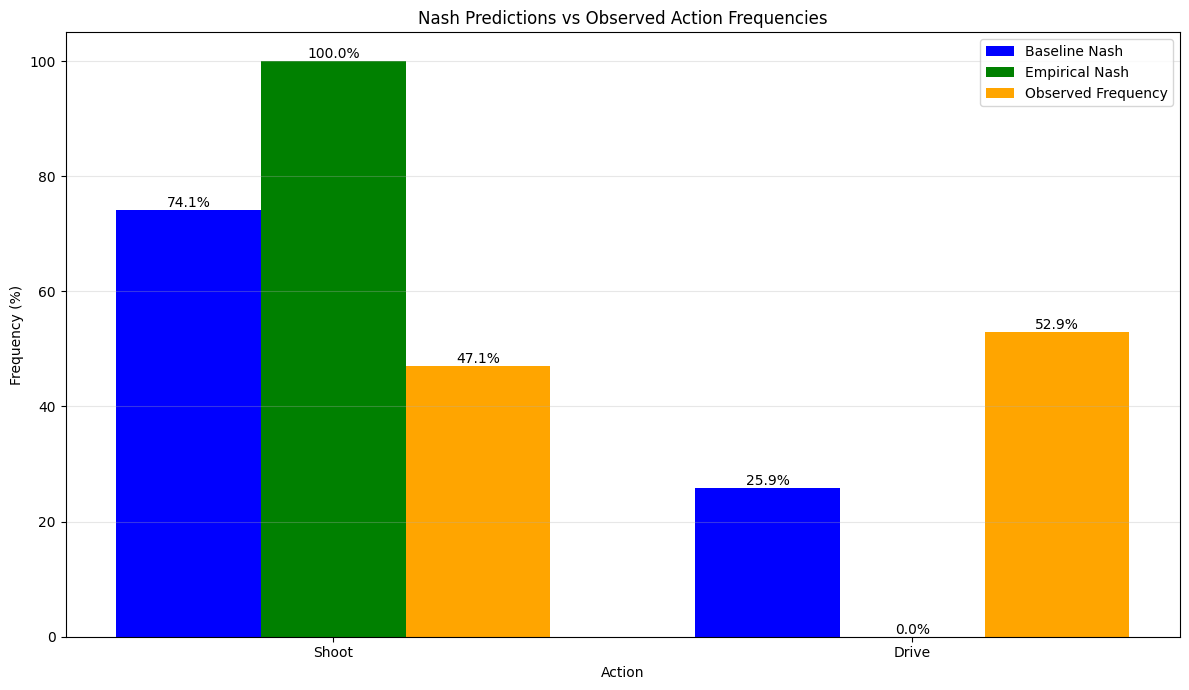

In [ ]:
# create graph
fig, br = plt.subplots(figsize=(12, 7))

# define action labels
actions = ['Shoot', 'Drive']

# label x axis as actions
x = np.arange(len(actions))
width = 0.25

# plot baseline bar
br.bar(x - width, [74.14, 25.86], width, label='Baseline Nash', color='blue')
# plot nash bar
br.bar(x, [emp_offence[0]*100, emp_offence[1]*100], width, label='Empirical Nash', color='green')
# plot empirical bar
br.bar(x + width, [shoot, drive], width, label='Observed Frequency', color='orange')

# plot graph details
br.set_xticks(x)
br.set_ylabel('Frequency (%)')
br.set_xlabel('Action')
br.set_xticklabels(actions)
br.set_title('Nash Predictions vs Observed Action Frequencies')
br.legend()
br.grid(axis='y', alpha=0.3)

# add % label
for bars in br.containers:
    br.bar_label(bars, fmt='%.1f%%')

# show graph output
plt.tight_layout()
plt.show()

3PT shot chart

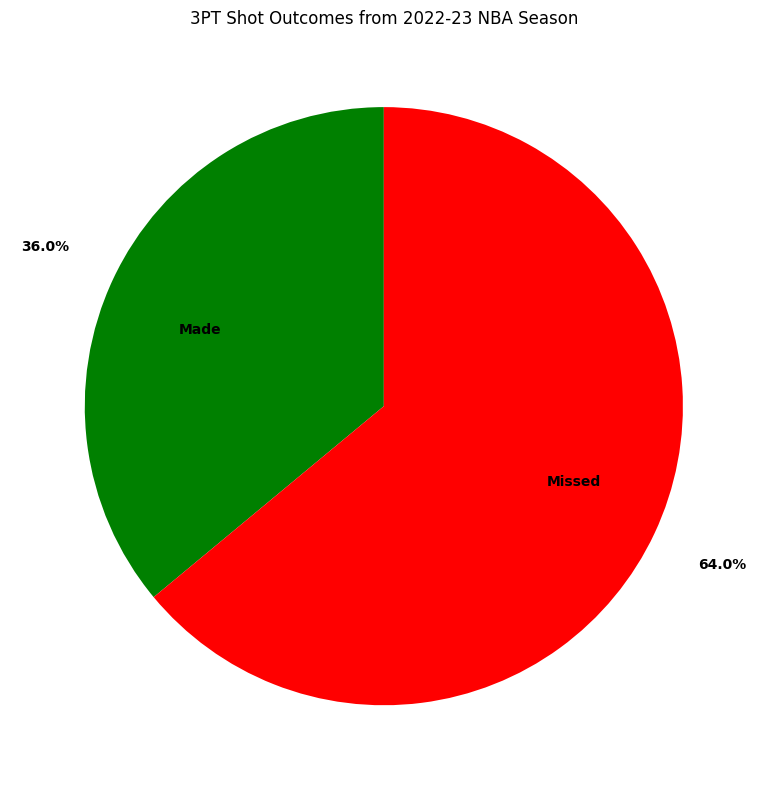

In [ ]:
# create graph
fig, pi = plt.subplots(figsize=(10,8))

# set pie chart details
labels = ['Made', 'Missed']
sizes = [scored_attempts, missed_attempts]
colors = ['green', 'red']
explode = (0.05, 0)

# plot pie chart
pi.pie(sizes, labels=labels, colors=colors, startangle=90, autopct='%1.1f%%',
       textprops={'weight': 'bold'}, pctdistance=1.25, labeldistance=.6)

# show pie chart output
plt.title('3PT Shot Outcomes from 2022-23 NBA Season')
plt.tight_layout()
plt.show()

**Data summarisation**

Gather all the key information needed from the empirical model

In [ ]:
print("Collective statistics from the Empirical Model:")
print(f"Total 3PT attempts {total_attempts}")
print(f"Shoot: {num_actions.get('Shoot', 0):,} ({shoot:.2f})")
print(f"Drive: {num_actions.get('Drive', 0):,} ({drive:.2f})")
print()
print(contest_analysis)

Collective statistics from the Empirical Model:
Total 3PT attempts 91233
Shoot: 91,233 (47.11)
Drive: 102,436 (52.89)

                  Attempts  Scored  Percentage
contest_estimate                              
Hard-Close Out       66938   23884   35.680779
Moderate Contest      6190    2350   37.964459
Sag Off              18105    6631   36.625242
